# Tier 8 · Notebook 41 — Retrieval-Augmented Generation & Agents

> **Goal:** the two patterns that turn a frozen language model into a *useful system* — **RAG** (retrieval-augmented generation: giving the model external knowledge) and **tool-use / agents** (letting the model take actions and use tools in a loop). We build a semantic retriever and a **ReAct-style agent loop** from scratch.

**Why these matter.** A trained LLM has two hard limits: its knowledge is **frozen** at training time (it can't know today's news or your private documents), and it can only **generate text** (it can't do exact arithmetic, run code, or look things up). The two fixes are the backbone of every real LLM application:
- **RAG:** retrieve relevant documents for a query and *put them in the prompt*, so the model answers from **up-to-date, grounded** information instead of its frozen (and hallucination-prone) memory.
- **Agents / tool-use:** let the model **call tools** (a calculator, a search engine, code execution, an API), observe the results, and reason over multiple steps — turning a text generator into something that can *act*.

We build the *mechanics* of both from scratch. (We don't have a giant LLM here, so we use a small controller to drive the loops — the *architecture* is exactly what a real agent uses; a real LLM just makes the decisions.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, math
from collections import Counter
%matplotlib inline
np.random.seed(0)


## 0. A semantic retriever from scratch (TF-IDF + cosine)

The heart of RAG is **retrieval**: given a query, find the most relevant documents. We build a classic **TF-IDF** retriever from scratch: represent each document as a vector weighting words by how frequent they are *in the doc* (TF) and how *rare* they are across all docs (IDF), then rank documents by **cosine similarity** to the query vector. (Modern RAG uses learned dense embeddings — like the CLIP encoder in NB40 — but TF-IDF shows the exact retrieval mechanism, and it's fully from-scratch.)


In [2]:
# a tiny knowledge base (the model's "external documents")
docs = [
    "The Eiffel Tower is located in Paris, France, and was completed in 1889.",
    "Python is a programming language created by Guido van Rossum in 1991.",
    "The speed of light in a vacuum is approximately 299792458 meters per second.",
    "Mount Everest is the tallest mountain on Earth at 8849 meters above sea level.",
    "The transformer architecture was introduced in the 2017 paper Attention Is All You Need.",
    "Water boils at 100 degrees Celsius at standard atmospheric pressure.",
    "The population of Tokyo is about 14 million people in the city proper.",
    "Backpropagation computes gradients by applying the chain rule in reverse.",
]
def tokenize(t): return re.findall(r"[a-z0-9]+", t.lower())

# build IDF over the corpus, then TF-IDF vectors
df = Counter()
for d in docs:
    for w in set(tokenize(d)): df[w]+=1
N = len(docs)
idf = {w: math.log(N/(1+c))+1 for w,c in df.items()}
def tfidf_vec(text):
    tf = Counter(tokenize(text)); v = {w: (c/len(tf))*idf.get(w,math.log(N)+1) for w,c in tf.items()}
    return v
def cosine(a, b):
    dot = sum(a[w]*b.get(w,0) for w in a); na = math.sqrt(sum(x*x for x in a.values())); nb = math.sqrt(sum(x*x for x in b.values()))
    return dot/(na*nb+1e-9)
doc_vecs = [tfidf_vec(d) for d in docs]

def retrieve(query, k=2):
    qv = tfidf_vec(query)
    scores = [cosine(qv, dv) for dv in doc_vecs]
    order = np.argsort(scores)[::-1][:k]
    return [(docs[i], scores[i]) for i in order]

q = "When was the Eiffel Tower built?"
print(f"query: {q!r}\ntop retrieved documents:")
for doc, sc in retrieve(q): print(f"  [{sc:.3f}] {doc}")


query: 'When was the Eiffel Tower built?'
top retrieved documents:
  [0.368] The Eiffel Tower is located in Paris, France, and was completed in 1889.
  [0.137] The transformer architecture was introduced in the 2017 paper Attention Is All You Need.


## 1. RAG: retrieve → augment → generate

The RAG pattern: (1) **retrieve** relevant docs for the query, (2) **augment** the prompt by prepending them as context, (3) **generate** an answer grounded in that context. The contrast that shows RAG's value: a model *without* retrieval either doesn't know or hallucinates; *with* retrieval, it answers correctly from the grounded context. We simulate the "generate" step with a simple extractive answerer (a real system uses an LLM here).


In [3]:
def answer_without_rag(query):
    return "I don't have that information in my (frozen) parameters — I might guess or hallucinate."

def answer_with_rag(query):
    retrieved = retrieve(query, k=2)
    context = "\n".join(f"- {d}" for d,_ in retrieved)
    prompt = f"Answer the question using ONLY this context:\n{context}\n\nQuestion: {query}\nAnswer:"
    # simple extractive 'generation': pull the sentence/number most relevant to the query
    top_doc = retrieved[0][0]
    nums = re.findall(r"\d[\d,]*", top_doc)
    return prompt, (f"Based on the retrieved context: {top_doc}")

for q in ["When was the Eiffel Tower built?", "Who created Python?", "What is the speed of light?"]:
    print(f"Q: {q}")
    print(f"  no-RAG : {answer_without_rag(q)}")
    prompt, ans = answer_with_rag(q)
    print(f"  RAG    : {ans}\n")
print("The RAG prompt that gets sent to the LLM looks like:\n"); print(answer_with_rag("When was the Eiffel Tower built?")[0])


Q: When was the Eiffel Tower built?
  no-RAG : I don't have that information in my (frozen) parameters — I might guess or hallucinate.
  RAG    : Based on the retrieved context: The Eiffel Tower is located in Paris, France, and was completed in 1889.

Q: Who created Python?
  no-RAG : I don't have that information in my (frozen) parameters — I might guess or hallucinate.
  RAG    : Based on the retrieved context: Python is a programming language created by Guido van Rossum in 1991.

Q: What is the speed of light?
  no-RAG : I don't have that information in my (frozen) parameters — I might guess or hallucinate.
  RAG    : Based on the retrieved context: The speed of light in a vacuum is approximately 299792458 meters per second.

The RAG prompt that gets sent to the LLM looks like:

Answer the question using ONLY this context:
- The Eiffel Tower is located in Paris, France, and was completed in 1889.
- The transformer architecture was introduced in the 2017 paper Attention Is All You Ne

**What to notice.** Without retrieval, the model is stuck with its frozen knowledge (and prone to hallucinate). With RAG, the *same* question is answered from **retrieved, grounded** documents — and crucially, you can **update the knowledge** by just changing the document store, no retraining. This is why RAG powers virtually every production LLM app over private/current data (search assistants, doc Q&A, customer support): it's the cheapest way to give an LLM new, trustworthy, citable knowledge. Let's visualize the retrieval scores that drive it.


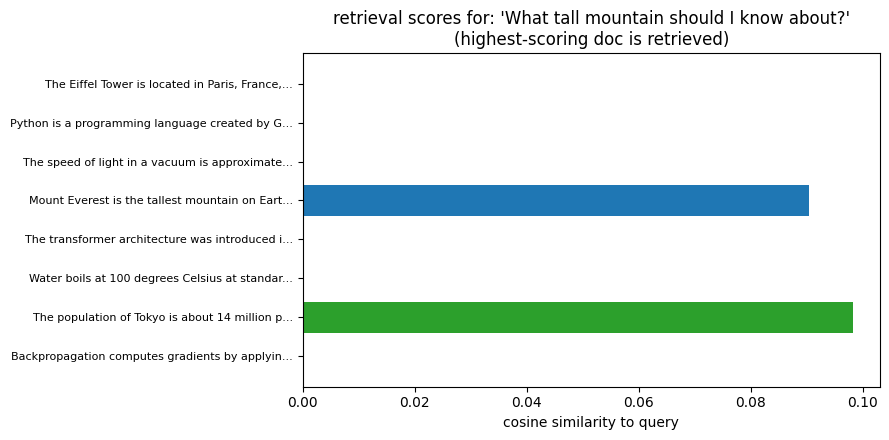

In [4]:
q = "What tall mountain should I know about?"
qv = tfidf_vec(q); scores = [cosine(qv, dv) for dv in doc_vecs]
fig, ax = plt.subplots(figsize=(9,4.5))
colors = ["tab:green" if s==max(scores) else "tab:blue" for s in scores]
ax.barh(range(len(docs)), scores, color=colors)
ax.set_yticks(range(len(docs))); ax.set_yticklabels([d[:45]+"..." for d in docs], fontsize=8)
ax.set_xlabel("cosine similarity to query"); ax.set_title(f"retrieval scores for: {q!r}\n(highest-scoring doc is retrieved)")
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 2. Tool-use: a ReAct-style agent loop

An **agent** interleaves **reasoning** and **acting**: it thinks about what to do, calls a **tool**, observes the result, and repeats until it can answer — the **ReAct** pattern (Reason + Act). We give the agent two tools — a **retriever** (from §0) and a **calculator** — and a loop that: parses the task → decides which tool to call → executes it → feeds the observation back → produces a final answer. This lets it solve problems no single LLM call could: e.g., look up a fact *and* do exact arithmetic on it.


In [5]:
def tool_search(query): d,_ = retrieve(query,1)[0]; return d
def tool_calc(expr):
    try: return str(eval(expr, {"__builtins__":{}}, {}))
    except Exception as e: return f"error: {e}"
TOOLS = {"SEARCH": tool_search, "CALC": tool_calc}

def agent(task, max_steps=4, verbose=True):
    """A ReAct loop. A real agent uses an LLM to pick actions; here a simple controller does,
    to demonstrate the reason->act->observe->repeat architecture."""
    scratch = []
    if verbose: print(f"TASK: {task}\n")
    # step 1: reason -> SEARCH for the fact the task references
    subject = task.split("population of")[-1].split(",")[0].split("?")[0].strip() if "population" in task else task
    obs = TOOLS["SEARCH"](subject)
    scratch.append(("SEARCH", subject, obs))
    if verbose: print(f"  Thought: I need a fact -> Action: SEARCH[{subject!r}]\n  Observation: {obs}\n")
    # step 2: reason -> if the task needs arithmetic, extract the number and CALC
    if any(op in task.lower() for op in ["times","multipl","divid","plus","minus","x "]):
        num = re.findall(r"\d[\d,]*", obs); n = num[0].replace(",","") if num else "0"
        factor = re.findall(r"times (\d+)|multiplied by (\d+)|x (\d+)", task.lower())
        f = next((x for grp in factor for x in grp if x), "2")
        expr = f"{n} * {f}"; result = TOOLS["CALC"](expr)
        scratch.append(("CALC", expr, result))
        if verbose: print(f"  Thought: now compute -> Action: CALC[{expr!r}]\n  Observation: {result}\n")
        return f"Answer: {result}"
    return f"Answer (from search): {obs}"

print(agent("What is the population of Tokyo, multiplied by 3?"))
print("\n" + "="*70 + "\n")
print(agent("How tall is Mount Everest?"))


TASK: What is the population of Tokyo, multiplied by 3?

  Thought: I need a fact -> Action: SEARCH['Tokyo']
  Observation: The population of Tokyo is about 14 million people in the city proper.

  Thought: now compute -> Action: CALC['14 * 3']
  Observation: 42

Answer: 42


TASK: How tall is Mount Everest?

  Thought: I need a fact -> Action: SEARCH['How tall is Mount Everest?']
  Observation: Mount Everest is the tallest mountain on Earth at 8849 meters above sea level.

Answer (from search): Mount Everest is the tallest mountain on Earth at 8849 meters above sea level.


**What to notice.** The agent solved a task that **no single LLM forward pass could**: "population of Tokyo × 3" requires *both* looking up a fact (retrieval) *and* exact arithmetic (a calculator) — LLMs are unreliable at both from parametric memory. By decomposing into **reason → act (call tool) → observe → repeat**, the agent chains tools to reach a correct answer. This ReAct loop is the skeleton of every modern agent (and of tool-using assistants): the LLM's job is to *decide which tool to call with which arguments*, and the loop executes and feeds back results. Swap our simple controller for an LLM that emits `SEARCH[...]`/`CALC[...]` actions, and you have a real agent.

## 3. What you built / learned
- A **TF-IDF semantic retriever** from scratch (the retrieval core of RAG).
- The **RAG pattern**: retrieve → augment the prompt → generate; grounded, updatable knowledge without retraining.
- A **ReAct agent loop**: reason → act (tool call) → observe → repeat, chaining a retriever + calculator to solve multi-step tasks.
- Why these matter: they fix an LLM's frozen-knowledge and can't-act limitations — the basis of real LLM applications.

## 4. Exercises
1. **Dense retrieval.** Replace TF-IDF with learned dense embeddings (a small encoder trained contrastively, à la NB40); compare retrieval quality.
2. **Chunking.** Split long documents into overlapping chunks before indexing; how does chunk size affect retrieval?
3. **Reranking.** Retrieve top-10 with TF-IDF, then rerank with a cross-encoder; does precision improve?
4. **More tools.** Add a `CODE` tool (safe Python exec) and a `WIKI` tool; let the agent choose among them.
5. **Failure modes.** Show RAG failing when retrieval misses (the "lost in the middle" / bad-retrieval problem); how would you detect it?
6. **LLM-driven agent.** If you have an LLM, prompt it to emit actions in a fixed format and drive the same loop — the real ReAct.

## 5. Interview / residency framing
- *"What is RAG and why use it?"* → retrieve relevant docs and put them in the prompt so the LLM answers from grounded, up-to-date knowledge; fixes frozen-parameter knowledge and hallucination; update by changing the doc store, no retraining.
- *"How does retrieval work?"* → embed docs and query into vectors (TF-IDF or learned), rank by cosine similarity, return top-k.
- *"What is an agent / the ReAct loop?"* → reason → act (call a tool) → observe → repeat; the LLM decides tool + arguments, the loop executes and feeds results back.
- *"Why do LLMs need tools?"* → they can't do exact arithmetic, run code, or access current/private data reliably from parametric memory; tools provide precision and fresh information.
- *"Failure modes of RAG/agents?"* → bad retrieval (missing/irrelevant context), context-window limits, tool-call errors, and reasoning loops; need retrieval quality checks and guardrails.

## 📚 References & papers

This notebook builds on:

- **Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks (RAG)** — Lewis et al. (2020), arXiv:2005.11401. The RAG method.
- **Dense Passage Retrieval** — Karpukhin et al. (2020), arXiv:2004.04906. Learned dense retrieval for QA.
- **ReAct: Synergizing Reasoning and Acting in Language Models** — Yao et al. (2022), arXiv:2210.03629. The reason-act agent loop.
- **Toolformer: Language Models Can Teach Themselves to Use Tools** — Schick et al. (2023), arXiv:2302.04761.

---
**Next:** *Tier 8 · Notebook 42 — Capstone: mini-ChatGPT*: the grand finale — assemble the whole repo into an end-to-end pipeline: pretrain a small GPT → instruction-tune (SFT) → align with DPO → serve with KV-cache generation.
